# Step 3: Fairness Audit

This notebook audits the baseline model's predictions (saved by notebook 02) for group differences, following survey section 4.2.

For each protected attribute (`RAC1P`, `SEX`) the module compares groups on:

- **Demographic Parity Difference** = highest group selection rate minus lowest
- **Disparate Impact Ratio** = lowest selection rate divided by highest (below 0.8 breaks the four-fifths rule)
- **Equal Opportunity Difference** = highest true-positive rate minus lowest
- **Equalized Odds (false-positive part)** = highest false-positive rate minus lowest

Two design choices to state in the report:
1. Groups with fewer than 30 test rows are excluded and reported, because rates on tiny groups are noise.
2. The thresholds (0.10 for the differences, 0.8 for the ratio) are documented defaults, not legal limits. A section below checks how much the result depends on them.

The result uses the shared `ModuleResult` format (metrics, risk 0 to 1, status, findings), so the Governance Risk Score and the dashboard can read it later.

In [1]:
import sys, os, json
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.audit.fairness import audit_fairness, DEFAULT_THRESHOLDS

RESULTS_DIR = os.path.abspath("../results")
preds = pd.read_csv(os.path.join(RESULTS_DIR, "baseline_predictions.csv"))
print(preds.shape)
preds.head()

(38642, 5)


,y_true,y_pred,y_proba,RAC1P,SEX
0,0,0,0.088930,9,2
1,1,1,0.902981,9,2
2,1,1,0.957361,1,1
3,1,1,0.988331,1,1
4,1,1,0.963164,1,2


## 1. Run the fairness audit

One call audits both protected attributes. The attribute risk is the worst of its four metric risks (0 at no gap, 0.5 exactly at the threshold, 1 at twice the threshold), so one failing metric is never averaged away.

In [2]:
groups = {"RAC1P": preds["RAC1P"], "SEX": preds["SEX"]}
result = audit_fairness(preds["y_true"], preds["y_pred"], groups)
print(result.summary())

Fairness: risk 1.000 (fail)
  - RAC1P: demographic parity difference 0.388 exceeds 0.10 (group 1 selected 61.5%, group 8 selected 22.7%).
  - RAC1P: disparate impact ratio 0.369 is below the four-fifths threshold (0.8).
  - RAC1P: equal opportunity difference 0.263 exceeds 0.10.
  - RAC1P: false-positive-rate difference 0.172 exceeds 0.10.
  - RAC1P: groups [4] excluded (fewer than 30 rows); fairness cannot be assessed for them.
  - SEX: demographic parity difference 0.104 exceeds 0.10 (group 1 selected 53.4%, group 2 selected 43.0%).


In [3]:
rows = []
for attr, m in result.metrics.items():
    rows.append({
        "attribute": attr,
        "demographic_parity_diff": m["demographic_parity_difference"],
        "disparate_impact_ratio": m["disparate_impact_ratio"],
        "equal_opportunity_diff": m["equal_opportunity_difference"],
        "fpr_diff": m["equalized_odds_fpr_difference"],
        "attribute_risk": m["attribute_risk"],
    })
pd.DataFrame(rows).set_index("attribute").round(4)

,demographic_parity_diff,disparate_impact_ratio,equal_opportunity_diff,fpr_diff,attribute_risk
attribute,,,,,
RAC1P,0.3879,0.3694,0.2626,0.1722,1.0000
SEX,0.1041,0.8050,0.0430,0.0458,0.5203


## 2. Per-group detail

`selection_rate` is the share the model predicts eligible. `true_rate` is the share actually eligible in the test data. `tpr` and `fpr` are the true-positive and false-positive rates. Group `n` is shown because small groups are unstable.

In [4]:
for attr, table in result.details.items():
    print(f"\n{attr}")
    print(table.round(4))


RAC1P
           n  selection_rate  true_rate     tpr     fpr  accuracy
group                                                            
1      15903          0.6152     0.5867  0.8642  0.2616    0.8122
2       1637          0.4258     0.4319  0.7228  0.2000    0.7666
3        502          0.3108     0.3446  0.6301  0.1429    0.7789
4          1          1.0000     1.0000  1.0000     NaN    1.0000
5         84          0.2976     0.2976  0.6800  0.1356    0.8095
6       7189          0.5606     0.5432  0.8489  0.2177    0.8185
7        139          0.3669     0.4173  0.6379  0.1728    0.7482
8       6706          0.2273     0.2692  0.6017  0.0894    0.8275
9       6481          0.3780     0.3862  0.7627  0.1360    0.8249

SEX
           n  selection_rate  true_rate     tpr     fpr  accuracy
group                                                            
1      20370          0.5336     0.5239  0.8313  0.2059    0.8136
2      18272          0.4295     0.4289  0.7883  0.1601    0.817

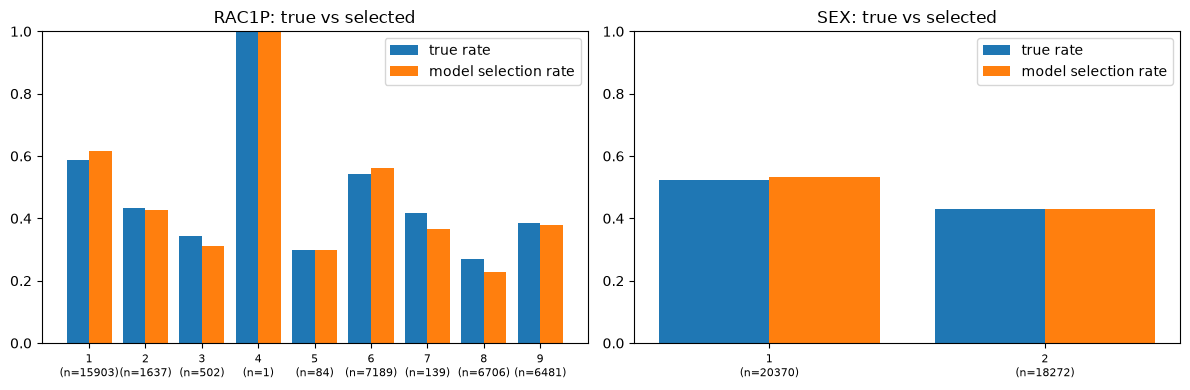

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (attr, table) in zip(axes, result.details.items()):
    x = np.arange(len(table))
    ax.bar(x - 0.2, table.true_rate, width=0.4, label="true rate")
    ax.bar(x + 0.2, table.selection_rate, width=0.4, label="model selection rate")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{g}\n(n={n})" for g, n in zip(table.index, table.n)], fontsize=8)
    ax.set_title(f"{attr}: true vs selected")
    ax.set_ylim(0, 1)
    ax.legend()
plt.tight_layout()
plt.show()

**How to read this.** The true rates already differ across groups (notebook 01 showed a gap of about 31 points across RAC1P in the raw data). So a nonzero Demographic Parity Difference does not by itself mean the model introduced the gap. Equal Opportunity Difference is the better test of model behaviour, because it compares true-positive rates, which condition on who is actually eligible. When the model's selection rate moves further from the true rate for one group than for others, that group is being treated differently by the model.

## 3. Sensitivity to the thresholds

A reviewer can ask why the thresholds are 0.10 and 0.8. This reruns the audit with all thresholds scaled by 0.5, 1 and 1.5 to show how much the fairness risk and status depend on that choice.

In [6]:
rows = []
for scale in (0.5, 1.0, 1.5):
    thr = {k: v * scale for k, v in DEFAULT_THRESHOLDS.items()}
    r = audit_fairness(preds["y_true"], preds["y_pred"], groups, thresholds=thr)
    rows.append({
        "threshold_scale": scale,
        "RAC1P_risk": r.metrics["RAC1P"]["attribute_risk"],
        "SEX_risk": r.metrics["SEX"]["attribute_risk"],
        "overall_risk": r.risk,
        "status": r.status,
    })
pd.DataFrame(rows).round(3)

,threshold_scale,RAC1P_risk,SEX_risk,overall_risk,status
0,0.5,1.0,1.000,1.0,fail
1,1.0,1.0,0.520,1.0,fail
2,1.5,1.0,0.347,1.0,fail


## 4. Save the result

Saved as JSON so the Governance Risk Score and the dashboard can load it without recomputing.

In [7]:
out = {
    "name": result.name,
    "risk": result.risk,
    "status": result.status,
    "findings": result.findings,
    "metrics": result.metrics,
    "group_tables": {a: t.reset_index().to_dict(orient="records") for a, t in result.details.items()},
}
path = os.path.join(RESULTS_DIR, "fairness_result.json")
with open(path, "w") as f:
    json.dump(out, f, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o))
print("Saved", path)

Saved E:\MTECH\Final_yr_project\results\fairness_result.json


## Summary and next step

- Audited both protected attributes with four fairness metrics and an explicit minimum group size.
- Produced a `ModuleResult` (risk, status, findings) and saved it to `results/fairness_result.json`.
- Checked how sensitive the outcome is to the thresholds.

**Next:** notebook 04, the Explainability audit (global SHAP importance and the sensitive-feature contribution ratio for RAC1P, SEX and POBP).